In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import joblib


features = pd.read_csv("../data/customer_features.csv")
train = pd.read_csv("../data/customer_clv_train.csv")

df = train.merge(features, on="cust_id", how="left")


In [2]:
# churn target
df["returned"] = (df["revenue_2018_2019"] > 0).astype(int)

In [3]:
X = df.drop(columns=["cust_id", "revenue_2018_2019", "returned"])
y = df["returned"]

In [4]:
# Three-way split: 60% train | 20% calibration | 20% validation
# The calibration set is used purely for probability calibration — never for model training
X_trainval, X_val, y_trainval, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42   # 0.25 × 0.80 = 0.20
)
print(f"Train: {len(X_train)}  Cal: {len(X_cal)}  Val: {len(X_val)}")


# LightGBM

In [5]:
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

lgb_param_grid = {
    "n_estimators": [500, 800, 1200],
    "learning_rate": [0.01, 0.02, 0.05],
    "num_leaves": [32, 64, 128],
    "min_child_samples": [20, 30, 50],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}

search_lgb = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight),
    param_distributions=lgb_param_grid,
    n_iter=20,                  # number of random combinations to try
    scoring="roc_auc",          # optimise for AUC
    cv=5,                       # 5-fold cross-validation
    random_state=42,      
    n_jobs=-1                   # Use all CPU Cores
)

search_lgb.fit(X_train, y_train)

print("Best params:", search_lgb.best_params_)
print("Best AUC:", search_lgb.best_score_)

lgb_model = search_lgb.best_estimator_
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 27284, number of negative: 47333
[LightGBM] [Info] Number of positive: 27285, number of negative: 47333
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042586 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6964
[LightGBM] [Info] Number of data points in the train set: 74617, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.365654 -> initscore=-0.550907
[LightGBM] [Info] Start training from score -0.550907
[LightGBM] [Info] Number of positive: 27285, number of negative: 47332
[LightGBM] [Info] Number of positive: 27285, number of negative: 47333
[LightGBM] [Info] Number of positive: 27285, number of negative: 47332
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.046620 seconds.
You can set `force_col_wise=true` to remove the overhe

,boosting_type,'gbdt'
,num_leaves,32
,max_depth,-1
,learning_rate,0.01
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [6]:
p_val_lgb = lgb_model.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_val, p_val_lgb)
ll = log_loss(y_val, p_val_lgb)

print("AUC:", auc)
print("Log loss:", ll)

AUC: 0.7215305885186442
Log loss: 0.6014984621482099


In [7]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(15)

,feature,importance
11,avg_size,1578
14,recency_days,1194
22,frequency_recency_ratio,853
23,revenue_recency_ratio,846
12,size_std,671
42,discount_rate,670
0,total_revenue,607
2,max_item_revenue,590
41,category_concentration,500
34,spending_trend,459


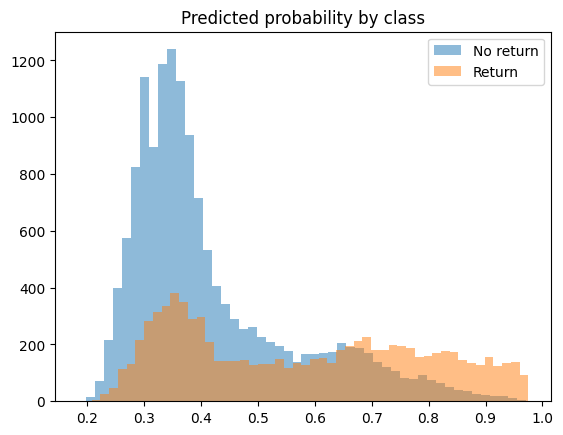

In [8]:
plt.hist(p_val_lgb[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_lgb[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# XGBoost

In [9]:
xgb_param_grid = {
    "n_estimators": [500, 800, 1200],
    "learning_rate": [0.01, 0.02, 0.05],
    "max_depth": [4, 6, 8],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5]
}

search_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric="logloss"),
    param_distributions=xgb_param_grid,
    n_iter=20,                  # number of random combinations to try
    scoring="roc_auc",          # optimise for AUC
    cv=5,                       # 5-fold cross-validation
    random_state=42,
    n_jobs=-1                   # Use all CPU Cores
)

search_xgb.fit(X_train, y_train)

print("Best params:", search_xgb.best_params_)
print("Best AUC:", search_xgb.best_score_)

xgb_model = search_xgb.best_estimator_

xgb_model.fit(X_train, y_train)

p_val_xgb = xgb_model.predict_proba(X_val)[:,1]

print("XGBoost AUC:", roc_auc_score(y_val, p_val_xgb))
print("XGBoost LogLoss:", log_loss(y_val, p_val_xgb))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:15:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:15:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:15:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:15:22] WARN

Best params: {'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.02, 'colsample_bytree': 0.8}
Best AUC: 0.7215913913099297


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:22:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC: 0.7218901968861751
XGBoost LogLoss: 0.6014961429084398


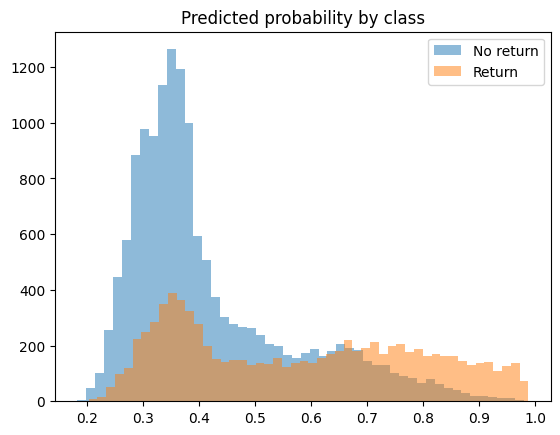

In [10]:
plt.hist(p_val_xgb[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_xgb[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# CatBoost

In [11]:
cat_param_grid = {
    "iterations": [500, 800, 1200],
    "learning_rate": [0.01, 0.02, 0.05],
    "depth": [4, 6, 8],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bylevel": [0.7, 0.8, 0.9],
    "min_child_samples": [20, 30, 50]
}

search_cat = RandomizedSearchCV(
    CatBoostClassifier(random_state=42, scale_pos_weight=scale_pos_weight, loss_function="Logloss", verbose=False),
    param_distributions=cat_param_grid,
    n_iter=20,                  # number of random combinations to try
    scoring="roc_auc",          # optimise for AUC
    cv=5,                       # 5-fold cross-validation
    random_state=42,
    n_jobs=-1                   # Use all CPU Cores
)

search_cat.fit(X_train, y_train)

print("Best params:", search_cat.best_params_)
print("Best AUC:", search_cat.best_score_)

cat_model = search_cat.best_estimator_
cat_model.fit(X_train, y_train)

p_val_cat = cat_model.predict_proba(X_val)[:,1]

print("CatBoost AUC:", roc_auc_score(y_val, p_val_cat))
print("CatBoost LogLoss:", log_loss(y_val, p_val_cat))

Best params: {'subsample': 0.8, 'min_child_samples': 20, 'learning_rate': 0.02, 'iterations': 800, 'depth': 6, 'colsample_bylevel': 0.7}
Best AUC: 0.7215275518804131
CatBoost AUC: 0.7218601028270567
CatBoost LogLoss: 0.6015089588592333


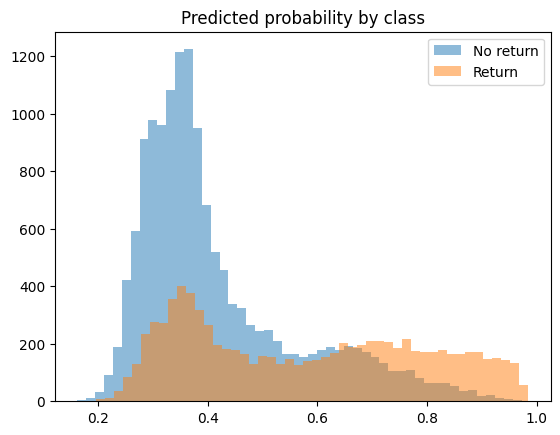

In [12]:
plt.hist(p_val_cat[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_cat[y_val == 1], bins=50, alpha=0.5, label="Return")

plt.legend()
plt.title("Predicted probability by class")
plt.show()

# Comparison

In [13]:
# Individual model comparison
results = {
    "LightGBM": roc_auc_score(y_val, p_val_lgb),
    "XGBoost":  roc_auc_score(y_val, p_val_xgb),
    "CatBoost": roc_auc_score(y_val, p_val_cat),
}
print("Individual model AUCs:")
for name, auc in results.items():
    print(f"  {name}: {auc:.4f}")

# Ensemble: simple average of the three model probabilities
p_val_ensemble = (p_val_lgb + p_val_xgb + p_val_cat) / 3
ensemble_auc = roc_auc_score(y_val, p_val_ensemble)
ensemble_ll  = log_loss(y_val, p_val_ensemble)
print(f"\nEnsemble (avg) AUC:      {ensemble_auc:.4f}")
print(f"Ensemble (avg) Log Loss: {ensemble_ll:.4f}")


Individual model AUCs:
  LightGBM: 0.7215
  XGBoost: 0.7219
  CatBoost: 0.7219

Ensemble (avg) AUC:      0.7221
Ensemble (avg) Log Loss: 0.6013


# Ensemble

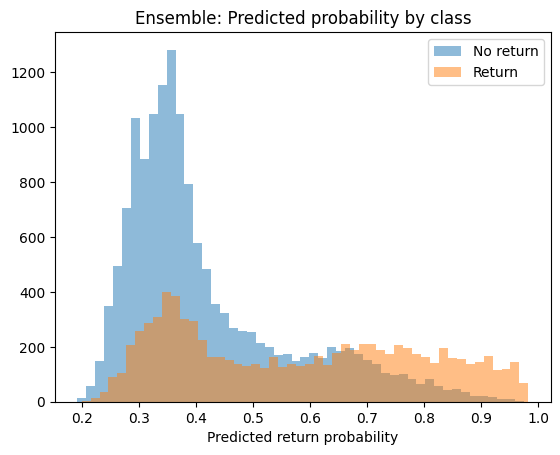

In [14]:
plt.hist(p_val_ensemble[y_val == 0], bins=50, alpha=0.5, label="No return")
plt.hist(p_val_ensemble[y_val == 1], bins=50, alpha=0.5, label="Return")
plt.legend()
plt.title("Ensemble: Predicted probability by class")
plt.xlabel("Predicted return probability")
plt.show()


# Probability Calibration

The histogram above shows the models are **under-confident**: predicted probabilities cluster around 0.2–0.5 for both classes, with heavy overlap. Isotonic regression calibration maps these raw scores to better-spread probabilities using the held-out calibration set — without touching the validation set used for evaluation.

In [34]:
from sklearn.isotonic import IsotonicRegression

# Get raw probabilities on the calibration set from each model
p_cal_lgb = lgb_model.predict_proba(X_cal)[:, 1]
p_cal_xgb = xgb_model.predict_proba(X_cal)[:, 1]
p_cal_cat = cat_model.predict_proba(X_cal)[:, 1]

# Fit one isotonic calibrator per model
iso_lgb = IsotonicRegression(out_of_bounds="clip").fit(p_cal_lgb, y_cal)
iso_xgb = IsotonicRegression(out_of_bounds="clip").fit(p_cal_xgb, y_cal)
iso_cat = IsotonicRegression(out_of_bounds="clip").fit(p_cal_cat, y_cal)

# Apply to validation set
p_val_lgb_cal = iso_lgb.transform(lgb_model.predict_proba(X_val)[:, 1])
p_val_xgb_cal = iso_xgb.transform(xgb_model.predict_proba(X_val)[:, 1])
p_val_cat_cal = iso_cat.transform(cat_model.predict_proba(X_val)[:, 1])
p_val_ens_cal = (p_val_lgb_cal + p_val_xgb_cal + p_val_cat_cal) / 3

print("Calibrated AUCs:")
print(f"  LightGBM:  {roc_auc_score(y_val, p_val_lgb_cal):.4f}")
print(f"  XGBoost:   {roc_auc_score(y_val, p_val_xgb_cal):.4f}")
print(f"  CatBoost:  {roc_auc_score(y_val, p_val_cat_cal):.4f}")
print(f"  Ensemble:  {roc_auc_score(y_val, p_val_ens_cal):.4f}")
print(f"  Log Loss:  {log_loss(y_val, p_val_ens_cal):.4f}")


Calibrated AUCs:
  LightGBM:  0.7204
  XGBoost:   0.7205
  CatBoost:  0.7207
  Ensemble:  0.7213
  Log Loss:  0.5758


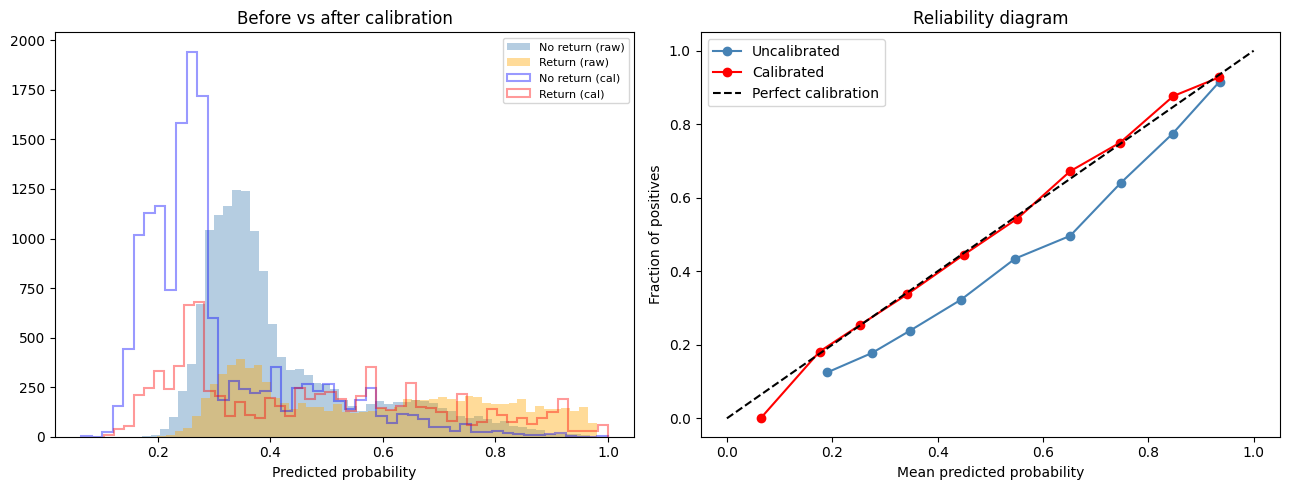

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: probability distributions before vs after calibration
ax = axes[0]
ax.hist(p_val_ensemble[y_val == 0], bins=50, alpha=0.4, label="No return (raw)", color="steelblue")
ax.hist(p_val_ensemble[y_val == 1], bins=50, alpha=0.4, label="Return (raw)",    color="orange")
ax.hist(p_val_ens_cal[y_val == 0],  bins=50, alpha=0.4, label="No return (cal)", color="blue",   histtype="step", linewidth=1.5)
ax.hist(p_val_ens_cal[y_val == 1],  bins=50, alpha=0.4, label="Return (cal)",    color="red",    histtype="step", linewidth=1.5)
ax.set_title("Before vs after calibration")
ax.set_xlabel("Predicted probability")
ax.legend(fontsize=8)

# Right: reliability diagram (perfect calibration = diagonal)
ax = axes[1]
for probs, label, color in [
    (p_val_ensemble, "Uncalibrated", "steelblue"),
    (p_val_ens_cal,  "Calibrated",   "red"),
]:
    frac_pos, mean_pred = calibration_curve(y_val, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", label=label, color=color)
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Reliability diagram")
ax.legend()

plt.tight_layout()
plt.show()


# Save Models

In [36]:
import os
os.makedirs("../models", exist_ok=True)


In [37]:
feature_cols = X.columns.tolist()

joblib.dump(feature_cols, "../models/feature_columns.pkl")

['../models/feature_columns.pkl']

In [38]:
# Save raw models
joblib.dump(lgb_model, "../models/churn_lgb_model.pkl")
joblib.dump(xgb_model, "../models/churn_xgb_model.pkl")
joblib.dump(cat_model,  "../models/churn_cat_model.pkl")

# Save isotonic calibrators
joblib.dump(iso_lgb, "../models/iso_lgb.pkl")
joblib.dump(iso_xgb, "../models/iso_xgb.pkl")
joblib.dump(iso_cat, "../models/iso_cat.pkl")

print("Models and calibrators saved.")


Models and calibrators saved.
